# Linear Regression Baseline and Split Comparison
**Competition**: Enefit Predict Energy Behavior of Prosumers  
**Metrics**: MAE, RMSE, R2  
**Goal**: Restore baseline-only features and compare one global model vs split producer and consumer models.

---

## Contents
1. [Import](#import)
2. [Environment](#environment)
3. [Load Data](#load)
4. [Preprocessing](#preprocessing)
5. [Training and Evaluation](#model)
6. [Visualization](#visualization)
7. [Feature Importance](#importance)


## Feature Setup

**Baseline features only**
- categorical and entity features
- basic time features
- weather and price features
- county aggregated features
- basic lag features

**Model comparison**
- one global linear regression model
- one producer model plus one consumer model


<a id="import"></a>
## 1. Import

Import required libraries.


In [31]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


<a id="environment"></a>
## 2. Environment

Set GPU or CPU environment.


In [32]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

<a id="load"></a>
## 3. Load Data

Load the processed dataset.


In [33]:
DATA_PATH = "../data/processed_data/full_processed.csv"
df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
print(df.columns.tolist())
display(df.head())

shape: (2018352, 64)
['row_id', 'prediction_unit_id', 'county', 'is_business', 'product_type', 'is_consumption', 'target', 'datetime', 'date', 'hour', 'weekday', 'month', 'day', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'days_in_month', 'data_block_id', 'eic_count', 'installed_capacity', 'temperature', 'dewpoint', 'rain', 'snowfall', 'surface_pressure', 'cloudcover_total', 'windspeed_10m', 'shortwave_radiation', 'direct_solar_radiation', 'temp_county', 'solar_county', 'direct_solar', 'cloud_county', 'wind_county', 'euros_per_mwh', 'lowest_price_per_mwh', 'highest_price_per_mwh', 'lag_1', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'rolling_std_168', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'dayofyear_sin', 'dayofyear_cos', 'weekofyear_sin', 'weekofyear_cos', 'quarter_sin', 'quarter_cos']


,row_id,prediction_unit_id,county,is_business,product_type,is_consumption,target,datetime,date,hour,...,month_sin,month_cos,day_sin,day_cos,dayofyear_sin,dayofyear_cos,weekofyear_sin,weekofyear_cos,quarter_sin,quarter_cos
0,0,0,0,0,1,0,0.713,2021-09-01 00:00:00,2021-09-01,0,...,-0.866025,-0.5,0.0,1.0,-0.861693,-0.50743,-0.822984,-0.568065,1.224647e-16,-1.0
1,122,0,0,0,1,0,1.132,2021-09-01 01:00:00,2021-09-01,1,...,-0.866025,-0.5,0.0,1.0,-0.861693,-0.50743,-0.822984,-0.568065,1.224647e-16,-1.0
2,244,0,0,0,1,0,0.490,2021-09-01 02:00:00,2021-09-01,2,...,-0.866025,-0.5,0.0,1.0,-0.861693,-0.50743,-0.822984,-0.568065,1.224647e-16,-1.0
3,366,0,0,0,1,0,0.496,2021-09-01 03:00:00,2021-09-01,3,...,-0.866025,-0.5,0.0,1.0,-0.861693,-0.50743,-0.822984,-0.568065,1.224647e-16,-1.0
4,488,0,0,0,1,0,0.149,2021-09-01 04:00:00,2021-09-01,4,...,-0.866025,-0.5,0.0,1.0,-0.861693,-0.50743,-0.822984,-0.568065,1.224647e-16,-1.0


In [34]:
## datetime 처리
df["datetime"] = pd.to_datetime(df["datetime"])
df["date"] = pd.to_datetime(df["date"])

## 결측 확인
na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(15))
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

row_id                0
prediction_unit_id    0
county                0
is_business           0
product_type          0
is_consumption        0
target                0
datetime              0
date                  0
hour                  0
weekday               0
month                 0
day                   0
dayofyear             0
weekofyear            0
dtype: int64


<a id="preprocessing"></a>
## 4. Preprocessing

Prepare datetime fields, missing values, baseline features, and producer/consumer splits.


In [35]:
drop_cols = ["target", "datetime", "date", "row_id"]

baseline_features = [
    "prediction_unit_id",
    "county",
    "is_business",
    "product_type",
    "is_consumption",
    "eic_count",
    "installed_capacity",
    "hour",
    "weekday",
    "month",
    "day",
    "dayofyear",
    "weekofyear",
    "temperature",
    "dewpoint",
    "rain",
    "snowfall",
    "surface_pressure",
    "cloudcover_total",
    "windspeed_10m",
    "shortwave_radiation",
    "euros_per_mwh",
    "lowest_price_per_mwh",
    "highest_price_per_mwh",
    "temp_county",
    "solar_county",
    "direct_solar",
    "cloud_county",
    "wind_county",
    "lag_1",
    "lag_24",
]

all_cols = [c for c in df.columns if c not in drop_cols]
baseline_features = [c for c in baseline_features if c in all_cols]
split_features = [c for c in baseline_features if c != "is_consumption"]

split_date = df["datetime"].quantile(0.8)
train_mask = df["datetime"] < split_date
valid_mask = df["datetime"] >= split_date

train_df = df.loc[train_mask].copy()
valid_df = df.loc[valid_mask].copy()

X_train_global = train_df[baseline_features]
X_valid_global = valid_df[baseline_features]
y_train = train_df["target"]
y_valid = valid_df["target"]

train_prod = train_df[train_df["is_consumption"] == 0].copy()
train_cons = train_df[train_df["is_consumption"] == 1].copy()
valid_prod = valid_df[valid_df["is_consumption"] == 0].copy()
valid_cons = valid_df[valid_df["is_consumption"] == 1].copy()

print("split_date:", split_date)
print("baseline feature count:", len(baseline_features))
print("global train shape:", X_train_global.shape)
print("global valid shape:", X_valid_global.shape)
print("producer train rows:", train_prod.shape[0])
print("producer valid rows:", valid_prod.shape[0])
print("consumer train rows:", train_cons.shape[0])
print("consumer valid rows:", valid_cons.shape[0])
print("baseline features:", baseline_features)


split_date: 2023-01-25 01:00:00
baseline feature count: 31
global train shape: (1614612, 31)
global valid shape: (403740, 31)
producer train rows: 807306
producer valid rows: 201870
consumer train rows: 807306
consumer valid rows: 201870
baseline features: ['prediction_unit_id', 'county', 'is_business', 'product_type', 'is_consumption', 'eic_count', 'installed_capacity', 'hour', 'weekday', 'month', 'day', 'dayofyear', 'weekofyear', 'temperature', 'dewpoint', 'rain', 'snowfall', 'surface_pressure', 'cloudcover_total', 'windspeed_10m', 'shortwave_radiation', 'euros_per_mwh', 'lowest_price_per_mwh', 'highest_price_per_mwh', 'temp_county', 'solar_county', 'direct_solar', 'cloud_county', 'wind_county', 'lag_1', 'lag_24']


<a id="model"></a>
## 5. Training and Evaluation

Train one global baseline model and compare it with separate producer and consumer baseline models.


In [36]:
def metric_dict(name, y_true, preds):
    return {
        "model": name,
        "mae": mean_absolute_error(y_true, preds),
        "mse": mean_squared_error(y_true, preds),
        "rmse": root_mean_squared_error(y_true, preds),
        "r2": r2_score(y_true, preds),
    }

global_model = LinearRegression()
global_model.fit(X_train_global, y_train)
global_preds = global_model.predict(X_valid_global)
global_metrics = metric_dict("global_baseline", y_valid, global_preds)

producer_model = LinearRegression()
consumer_model = LinearRegression()

producer_model.fit(train_prod[split_features], train_prod["target"])
consumer_model.fit(train_cons[split_features], train_cons["target"])

producer_preds = producer_model.predict(valid_prod[split_features])
consumer_preds = consumer_model.predict(valid_cons[split_features])

split_pred_df = pd.concat([
    pd.DataFrame({"row_id": valid_prod["row_id"].values, "pred": producer_preds}),
    pd.DataFrame({"row_id": valid_cons["row_id"].values, "pred": consumer_preds}),
], ignore_index=True)

split_preds = (
    valid_df[["row_id"]]
    .merge(split_pred_df, on="row_id", how="left")
    ["pred"]
    .to_numpy()
)

split_metrics = metric_dict("split_prod_cons", y_valid, split_preds)
producer_metrics = metric_dict("producer_only", valid_prod["target"], producer_preds)
consumer_metrics = metric_dict("consumer_only", valid_cons["target"], consumer_preds)

results_df = pd.DataFrame([global_metrics, split_metrics])
results_df["mae_improvement"] = results_df.loc[0, "mae"] - results_df["mae"]

segment_results_df = pd.DataFrame([producer_metrics, consumer_metrics])

print("Global vs split comparison")
display(results_df)

print("Segment validation metrics")
display(segment_results_df)


Global vs split comparison


,model,mae,mse,rmse,r2,mae_improvement
0,global_baseline,46.347810,20355.168119,142.671539,0.981068,0.000000
1,split_prod_cons,46.454543,19355.455436,139.123885,0.981997,-0.106733


Segment validation metrics


,model,mae,mse,rmse,r2
0,producer_only,49.474510,24400.300171,156.205954,0.935794
1,consumer_only,43.434576,14310.610701,119.626965,0.991606


<a id="visualization"></a>
## 6. Visualization

### 6.1 Global vs split model comparison


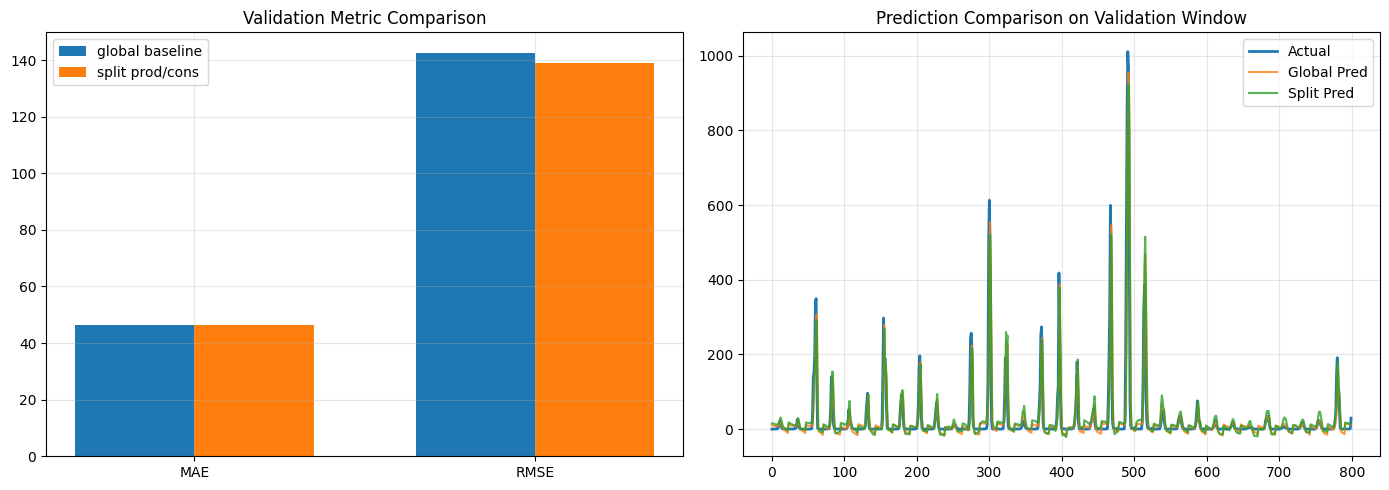

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_names = ["mae", "rmse"]
bar_width = 0.35
x = np.arange(len(metric_names))

global_values = [global_metrics[m] for m in metric_names]
split_values = [split_metrics[m] for m in metric_names]

axes[0].bar(x - bar_width / 2, global_values, width=bar_width, label="global baseline")
axes[0].bar(x + bar_width / 2, split_values, width=bar_width, label="split prod/cons")
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.upper() for m in metric_names])
axes[0].set_title("Validation Metric Comparison")
axes[0].grid(alpha=0.3)
axes[0].legend()

sample_size = min(800, len(y_valid))
sample_idx = np.arange(sample_size)
axes[1].plot(sample_idx, y_valid.iloc[:sample_size].values, label="Actual", linewidth=2)
axes[1].plot(sample_idx, global_preds[:sample_size], label="Global Pred", alpha=0.8)
axes[1].plot(sample_idx, split_preds[:sample_size], label="Split Pred", alpha=0.8)
axes[1].set_title("Prediction Comparison on Validation Window")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### 6.2 Scatter and segment comparison


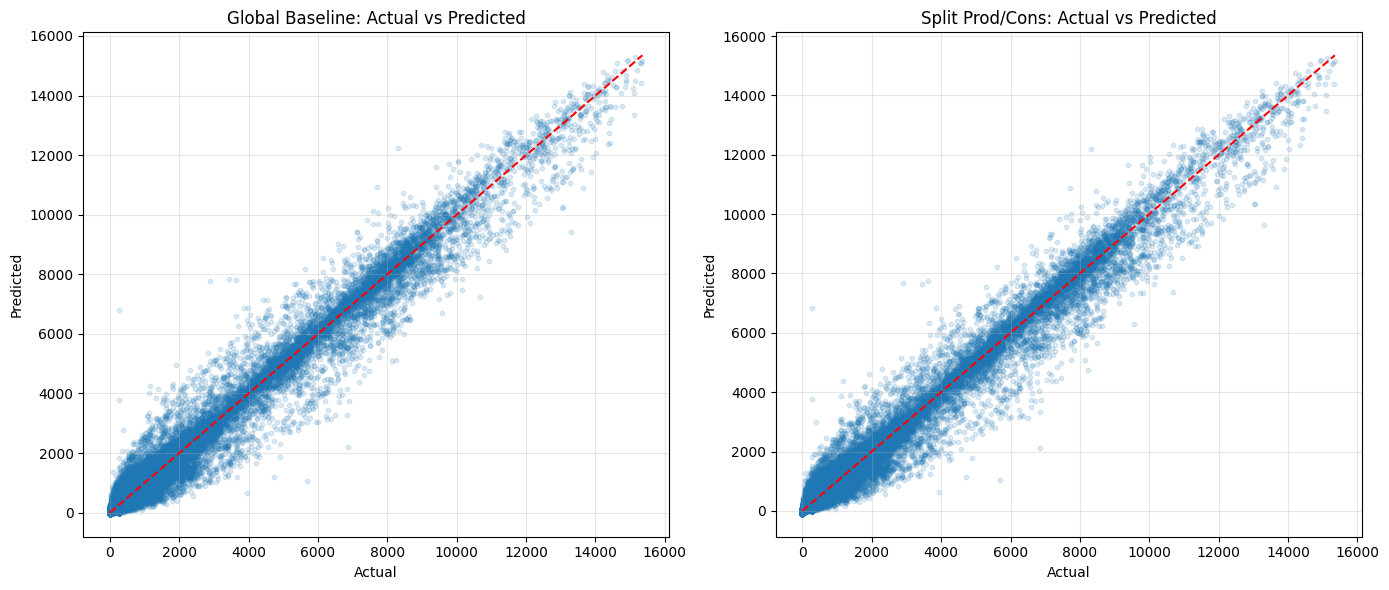

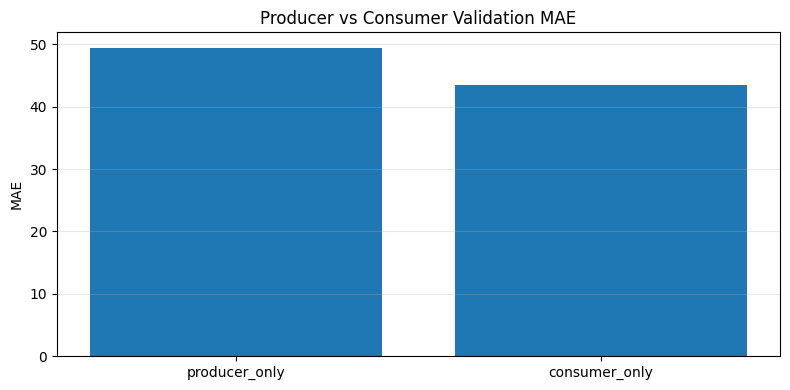

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_valid, global_preds, alpha=0.15, s=10)
axes[0].plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], color="red", linestyle="--")
axes[0].set_title("Global Baseline: Actual vs Predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_valid, split_preds, alpha=0.15, s=10)
axes[1].plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], color="red", linestyle="--")
axes[1].set_title("Split Prod/Cons: Actual vs Predicted")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(segment_results_df["model"], segment_results_df["mae"])
plt.title("Producer vs Consumer Validation MAE")
plt.ylabel("MAE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


<a id="importance"></a>
## 7. Feature Importance

Compare absolute coefficient values for the global, producer, and consumer baseline models.


Top 10 global baseline feature importances


,feature,coef,abs_coef
15,rain,-4.643468,4.643468
13,temperature,-3.293787,3.293787
14,dewpoint,3.140691,3.140691
9,month,1.927835,1.927835
4,is_consumption,1.171763,1.171763
8,weekday,-1.098624,1.098624
7,hour,-1.002843,1.002843
29,lag_1,0.883530,0.883530
19,windspeed_10m,0.760914,0.760914
16,snowfall,0.629742,0.629742


Top 10 producer feature importances


,feature,coef,abs_coef
14,rain,-23.427043,23.427043
15,snowfall,-11.308067,11.308067
8,month,-10.501762,10.501762
12,temperature,-9.534001,9.534001
13,dewpoint,8.953726,8.953726
18,windspeed_10m,2.009458,2.009458
6,hour,-0.913063,0.913063
28,lag_1,0.803891,0.803891
7,weekday,0.452214,0.452214
10,dayofyear,0.377290,0.377290


Top 10 consumer feature importances


,feature,coef,abs_coef
8,month,-24.938264,24.938264
15,snowfall,14.144775,14.144775
14,rain,10.035418,10.035418
12,temperature,3.915038,3.915038
13,dewpoint,-3.708944,3.708944
7,weekday,-1.781388,1.781388
6,hour,-1.028347,1.028347
28,lag_1,0.906808,0.906808
9,day,-0.801240,0.801240
10,dayofyear,0.776207,0.776207


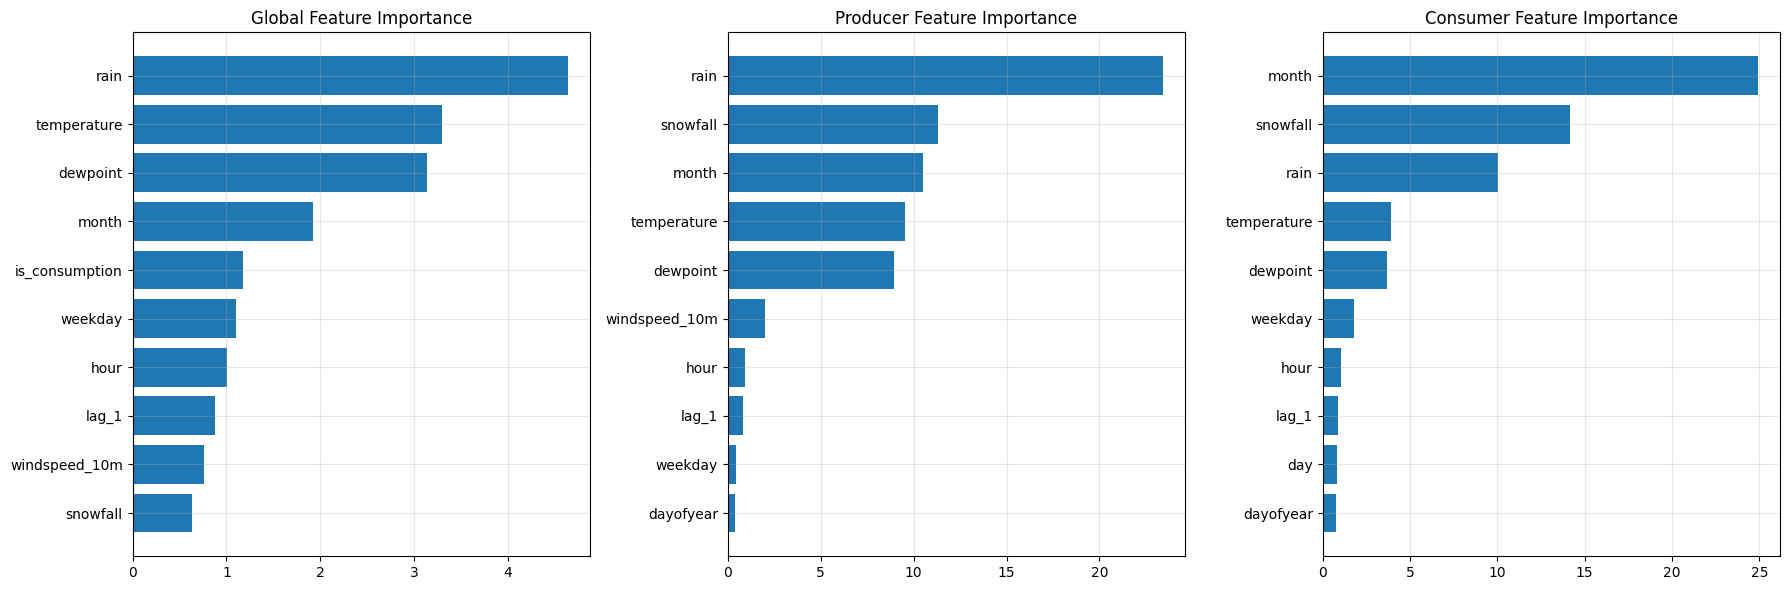

In [39]:
global_coef_df = pd.DataFrame({
    "feature": baseline_features,
    "coef": global_model.coef_,
})
global_coef_df["abs_coef"] = global_coef_df["coef"].abs()
global_coef_df = global_coef_df.sort_values("abs_coef", ascending=False)

producer_coef_df = pd.DataFrame({
    "feature": split_features,
    "coef": producer_model.coef_,
})
producer_coef_df["abs_coef"] = producer_coef_df["coef"].abs()
producer_coef_df = producer_coef_df.sort_values("abs_coef", ascending=False)

consumer_coef_df = pd.DataFrame({
    "feature": split_features,
    "coef": consumer_model.coef_,
})
consumer_coef_df["abs_coef"] = consumer_coef_df["coef"].abs()
consumer_coef_df = consumer_coef_df.sort_values("abs_coef", ascending=False)

print("Top 10 global baseline feature importances")
display(global_coef_df.head(10))

print("Top 10 producer feature importances")
display(producer_coef_df.head(10))

print("Top 10 consumer feature importances")
display(consumer_coef_df.head(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, title, coef_df in [
    (axes[0], "Global", global_coef_df),
    (axes[1], "Producer", producer_coef_df),
    (axes[2], "Consumer", consumer_coef_df),
]:
    top_features = coef_df.head(10).sort_values("abs_coef")
    ax.barh(top_features["feature"], top_features["abs_coef"])
    ax.set_title(f"{title} Feature Importance")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
